Mean:  6.8
Median:  7.0
Mode:  7
Variance:  18.96
Std:  4.354308211415448
Range:  14


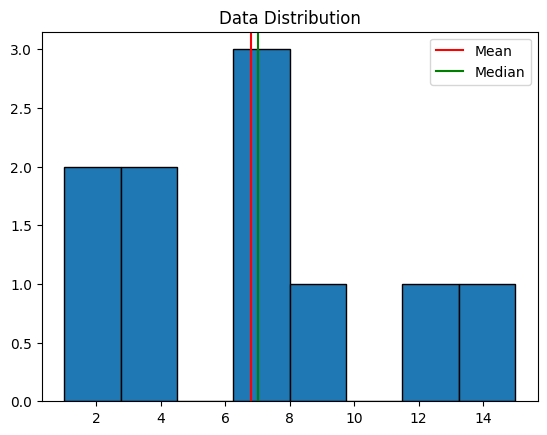


Normal - Mean:  6.8 Median:  7.0
Outlier - Mean:  106.5 Median:  7.0


In [1]:
#Day-1
import numpy as np
import matplotlib.pyplot as plt

data = np.array([4, 7, 13, 2, 1, 7, 9, 15, 7, 3])

#Mean
print("Mean: ",np.mean(data))

#Median
print("Median: ", np.median(data))

#Mode 
values, counts = np.unique(data, return_counts=True)
print("Mode: ", values[np.argmax(counts)])

#Variance and std
print("Variance: ", np.var(data))
print("Std: ", np.std(data))

#Range
print("Range: ", np.max(data) - np.min(data))

#Visualize
plt.hist(data, bins=8, edgecolor='black')
plt.axvline(np.mean(data),color='r',label='Mean')
plt.axvline(np.median(data),color='g',label='Median')
plt.legend()
plt.title('Data Distribution')
plt.show()

#Outlier experiment
data_normal = np.array([4, 7, 13, 2, 1, 7, 9, 15, 7, 3])
data_outlier = np.array([4, 7, 13, 2, 1, 7, 9, 15, 7, 1000])
print("\nNormal - Mean: ", np.mean(data_normal), "Median: ",np.median(data_normal))
print("Outlier - Mean: ", np.mean(data_outlier), "Median: ", np.median(data_outlier))

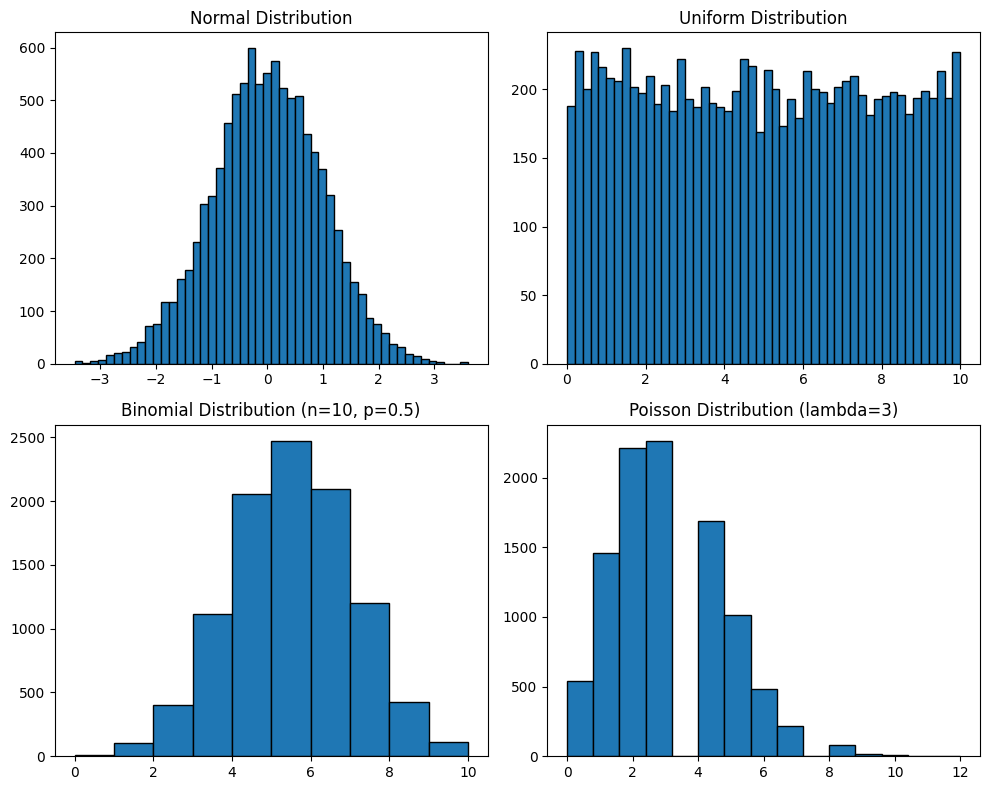

In [1]:
#Day-2
import numpy as np
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(10,8))

#Normal
data = np.random.normal(0, 1, 10000)
axes[0,0].hist(data, bins=50, edgecolor='black')
axes[0,0].set_title('Normal Distribution')

#Uniform
data = np.random.uniform(0, 10, 10000)
axes[0,1].hist(data, bins=50, edgecolor='black')
axes[0,1].set_title('Uniform Distribution')

#Binomial
data = np.random.binomial(n=10, p=0.5, size=10000)
axes[1,0].hist(data, bins=10, edgecolor='black')
axes[1,0].set_title('Binomial Distribution (n=10, p=0.5)')

#Poisson
data = np.random.poisson(lam=3, size=10000)
axes[1,1].hist(data, bins=15, edgecolor='black')
axes[1,1].set_title('Poisson Distribution (lambda=3)')

plt.tight_layout()
plt.show()

In [3]:
#Day-3
#Exercise-1
#Simulating the medical test
import numpy as np

#Parameters
n = 100000
disease_rate = 0.01
true_positive_rate = 0.90
false_positive_rate = 0.09

#Simulate population
has_disease = np.random.rand(n) < disease_rate

#Simulate test results
test_positive = np.where(
    has_disease,
    np.random.rand(n) < true_positive_rate,     #True Positive Rate
    np.random.rand(n) < false_positive_rate     #False Positive Rate
)

#Calculate P(disease | Positive test)
positive = test_positive
disease_and_positive = has_disease & test_positive

p_disease_given_positive = np.sum(disease_and_positive) / np.sum(positive)
print(f"P(disease | positive): {p_disease_given_positive:.4f}")

P(disease | positive): 0.0893


In [ ]:
#Exercise-2
#Spam filter simulation
''' 30% of emails are spam
P(word "win" | spam) = 0.6
P(word "win" | not spam) = 0.05
'''

p_spam = 0.30
p_win_given_spam = 0.60
p_win_given_not_spam = 0.05

#Bayes theorem
p_win = p_win_given_spam * p_spam + p_win_given_not_spam * (1 - p_spam)
p_spam_given_win = (p_win_given_spam * p_spam) / p_win

print(f"P(spam | contains 'win'): {p_spam_given_win:.4f}")

P(spam | contains 'win'): 0.8372


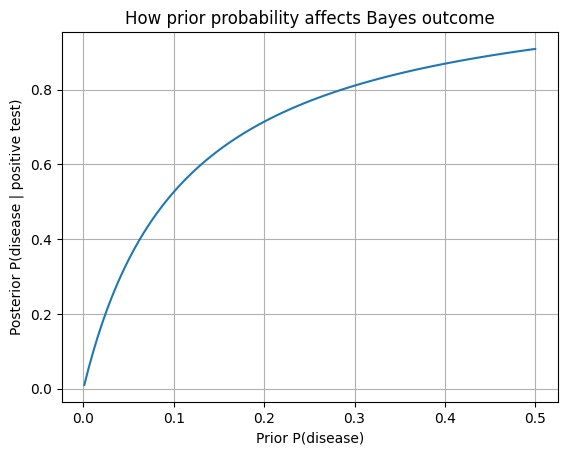

In [8]:
#Exercise-3
import matplotlib.pyplot as plt
import numpy as np

#How does P(disease | positive) change with different disease routes?
true_positive_rate = 0.90
false_positive_rate = 0.09
disease_rates = np.linspace(0.001,0.500,100)
posteriors = []

for rate in disease_rates:
    p_positive = true_positive_rate * rate + false_positive_rate * (1 - rate)
    posterior = (true_positive_rate * rate) / p_positive
    posteriors.append(posterior)

plt.plot(disease_rates, posteriors)
plt.xlabel('Prior P(disease)')
plt.ylabel('Posterior P(disease | positive test)')
plt.title('How prior probability affects Bayes outcome')
plt.grid()
plt.show()

Covariance matrix:
 [[ 8.58755909 17.60327401]
 [17.60327401 39.62607591]]
Correlation matrix:
 [[1.         0.95426291]
 [0.95426291 1.        ]]


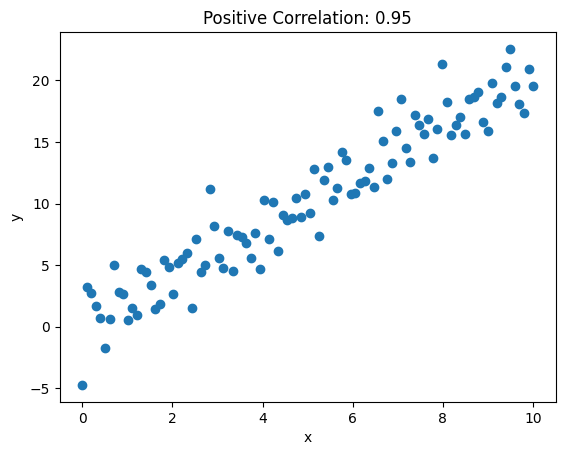

Negative Correlation: -0.9545996975889842
No Correlation: -0.06670170428927993


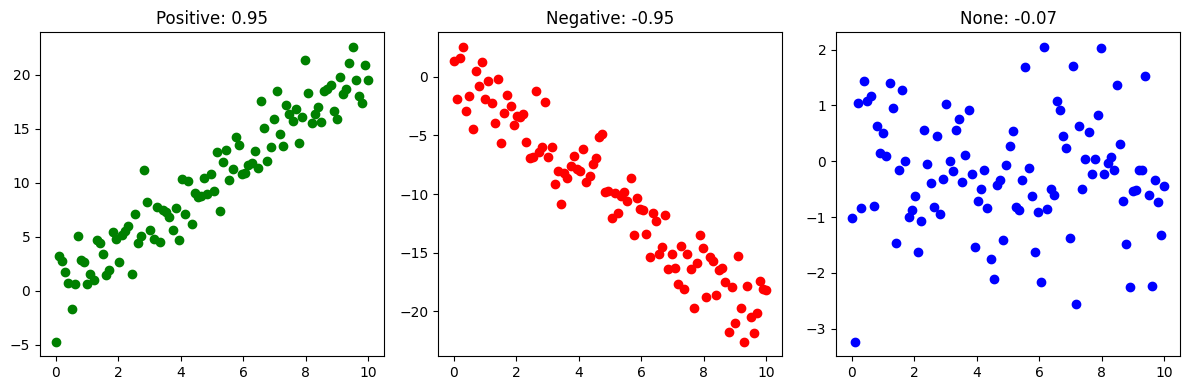

In [2]:
#Day-4
import numpy as np
import matplotlib.pyplot as plt

#Positive correlation
x = np.linspace(0, 10, 100)
y = 2 * x + np.random.randn(100) * 2

print("Covariance matrix:\n", np.cov(x,y))
print("Correlation matrix:\n", np.corrcoef(x,y))

plt.scatter(x,y)
plt.title(f'Positive Correlation: {np.corrcoef(x,y)[0,1]:.2f}')
plt.xlabel('x')
plt.ylabel('y')
plt.show()

#Negative Correlation
y_neg = -2 * x + np.random.randn(100) * 2
print("Negative Correlation:", np.corrcoef(x,y_neg)[0,1])

#No correlation
y_none = np.random.randn(100)
print("No Correlation:", np.corrcoef(x, y_none)[0,1])

#To visualise all the three
fig, axes = plt.subplots(1, 3, figsize=(12,4))

axes[0].scatter(x, y, color='green')
axes[0].set_title(f'Positive: {np.corrcoef(x,y)[0,1]:.2f}')

axes[1].scatter(x, y_neg, color='red')
axes[1].set_title(f'Negative: {np.corrcoef(x, y_neg)[0,1]:.2f}')

axes[2].scatter(x, y_none, color='blue')
axes[2].set_title(f'None: {np.corrcoef(x, y_none)[0,1]:.2f}')

plt.tight_layout()
plt.show()

Mean:  -0.046106981070322156
Median:  -0.012521337778042409
Mode:  -3.2465516047198695
Variance:  0.9861843890987302
Standard Deviation:  0.9930681694117127


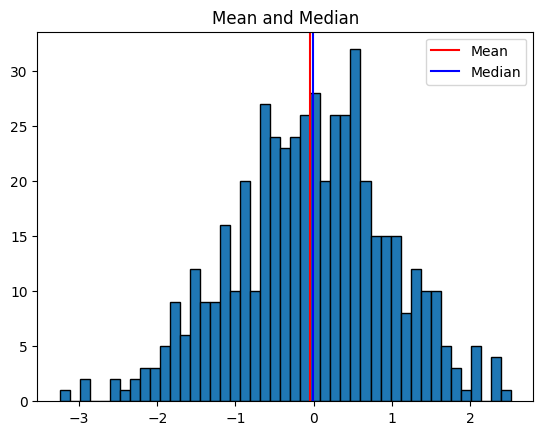

In [8]:
#Practice
#Exercise-1
#Generate a dataset of 500 random normal numbers, compute mean, median, mode, variance, std and plot a histogram with mean and median marked.
import numpy as np
import matplotlib.pyplot as plt

data = np.random.normal(0, 1, 500)

#Mean
print("Mean: ", np.mean(data))

#Median
print("Median: ", np.median(data))

#Mode
values, counts = np.unique(data, return_counts=True)
print("Mode: ", values[np.argmax(counts)])

#Variance and Standard Deviation
print("Variance: ", np.var(data))
print("Standard Deviation: ", np.std(data))

#Histogram
plt.hist(data, bins=45, edgecolor='black')
plt.axvline(np.mean(data), color='r', label='Mean')
plt.axvline(np.median(data), color='b', label='Median')
plt.legend()
plt.title("Mean and Median")
plt.show()

In [37]:
#Exercise-2
#Add 3 extreme outliers to the dataset and recompute. Print how much mean vs median shifted.
import numpy as np
import matplotlib.pyplot as plt

data = np.random.normal(0, 1, 500)

#Mean
print("Mean: ", np.mean(data))

#Median
print("Median: ", np.median(data))

#Mode
values, counts = np.unique(data, return_counts=True)
print("Mode: ", values[np.argmax(counts)])

#Variance and Standard Deviation
print("Variance: ", np.var(data))
print("Standard Deviation: ", np.std(data))

#Outlier Experiment
outliers = np.array([1000, -1000, 999])
data_outlier = np.append(data, outliers)

#Mean and Median
print("Mean: ", np.mean(data_outlier))
print("Median: ", np.median(data_outlier))

#Shift in results
mean_shift =  np.mean(data) - np.mean(data_outlier)
median_shift =  np.median(data) - np.median(data_outlier)

print(f'Mean Shift: {mean_shift:.4f}')
print(f'Median Shift: {median_shift:.4f}')

Mean:  -0.0226875606306988
Median:  0.035074831299831265
Mode:  -2.900386922749001
Variance:  1.0833173849921913
Standard Deviation:  1.0408253383695996
Mean:  1.963531251858152
Median:  0.04021386223348628
Mean Shift: -1.9862
Median Shift: -0.0051


Mean:  0.5023


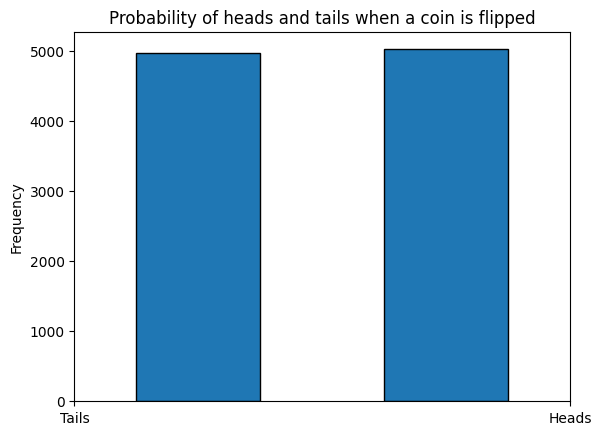

In [8]:
#Exercise-3
#Simulate 10000 coin flips using binomial distribution. Plot the results and verify P(heads) is close to 0.5.
import numpy as np
import matplotlib.pyplot as plt

flips = np.random.binomial(n=1, p=0.5, size=10000)

print("Mean: ", np.mean(flips))

plt.hist(flips, bins=2, edgecolor='black', rwidth=0.5)
plt.xticks([0,1], ['Tails', 'Heads'])
plt.title("Probability of heads and tails when a coin is flipped")
plt.ylabel('Frequency')
plt.show()


In [12]:
#Exercise-4
'''Simulate a Naive Bayes spam filter:
40% emails are spam
P("free" | spam) = 0.7
P("free" | not spam) = 0.1
Calculate P(spam | email contains "free")
''' 
import numpy as np

p_spam = 0.4
p_free_given_spam = 0.7
p_free_given_not_spam = 0.1

#Bayes Theorem
p_free = p_free_given_spam * p_spam + p_free_given_not_spam * (1-p_spam)
p_spam_given_free = (p_spam * p_free_given_spam)/p_free

print("Probability of free emails: ", p_free)
print("P(spam | email contains 'free'): ", p_spam_given_free)

Probability of free emails:  0.33999999999999997
P(spam | email contains 'free'):  0.8235294117647058


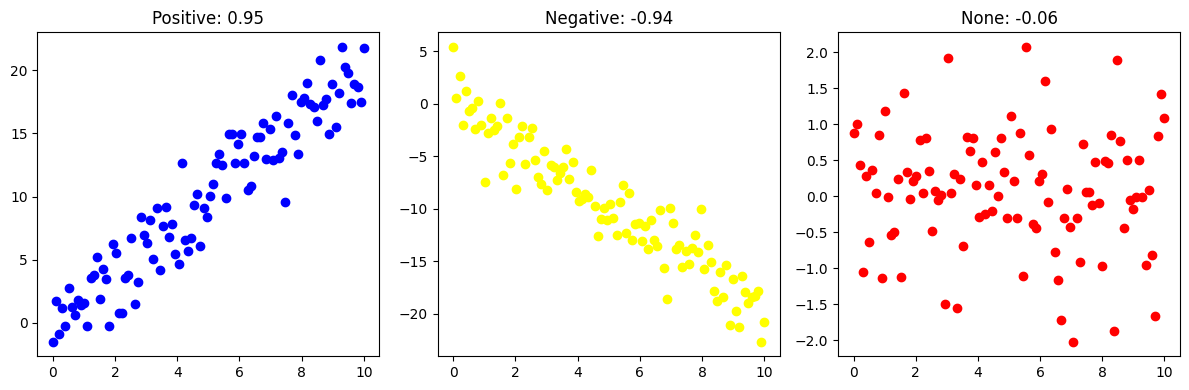

In [15]:
#Exercise-5
#Generate two correlated variables and one uncorrelated variable. Plot all three scatter plots side by side and print their correlation values.
import numpy as np
import matplotlib.pyplot as plt

x = np.linspace(0, 10, 100)

#positive correlation
y = 2 * x + np.random.randn(100) * 2

#negative correlation
y_neg = -2 * x + np.random.randn(100) * 2

#no correlation
y_no = np.random.randn(100)

#To visualise all the three
fig, axes = plt.subplots(1, 3, figsize=(12,4))

#plotting
axes[0].scatter(x, y, color='blue')
axes[0].set_title(f'Positive: {np.corrcoef(x, y)[0,1]:.2f}')

axes[1].scatter(x, y_neg, color='yellow')
axes[1].set_title(f'Negative: {np.corrcoef(x, y_neg)[0,1]:.2f}')

axes[2].scatter(x, y_no, color='red')
axes[2].set_title(f'None: {np.corrcoef(x, y_no)[0,1]:.2f}')

plt.tight_layout()
plt.show()

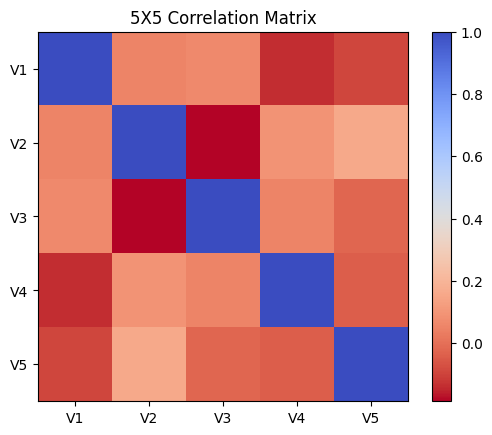

In [38]:
#Exercise-6
#Generate a 5x5 correlation matrix from random data and visualize it as a heatmap using plt.imshow() with plt.colorbar()
import numpy as np
import matplotlib.pyplot as plt

a = np.random.randn(100, 5)

#Correlation matrix
corr_matrix = np.corrcoef(a.T)
plt.imshow(corr_matrix, cmap='coolwarm_r')
plt.colorbar()
plt.title('5X5 Correlation Matrix')
plt.xticks(range(5), ['V1', 'V2', 'V3', 'V4', 'V5'])
plt.yticks(range(5), ['V1', 'V2', 'V3', 'V4', 'V5'])
plt.show()


In [33]:
#Exercise-7
#Simulate the Monty Hall problem
import numpy as np 
def monty_hall(switch):
    n = 10000
    wins = 0
    for _ in range(n):
        car = np.random.randint(0, 3)
        choice = np.random.randint(0, 3)
        if switch:
            #Switch to the other door
            wins += (choice != car)
        else:
            wins += (choice == car)
    return wins / n

print("Win rate without switching: ", monty_hall(False))
print("Win rate with switching: ", monty_hall(True))



Win rate without switching:  0.3288
Win rate with switching:  0.6701


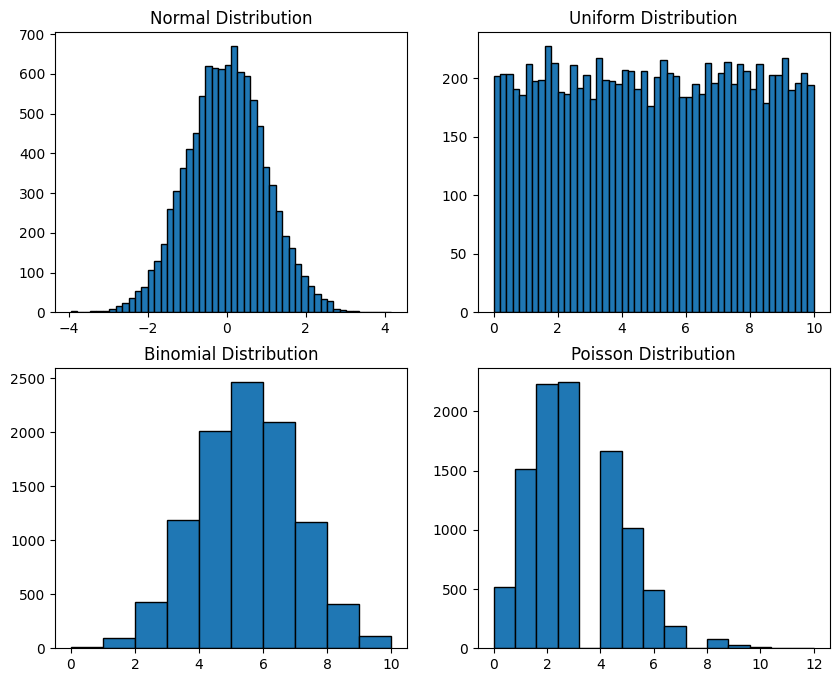

In [35]:
#Exercise-8
#Plot four distributions (normal, uniform, binomial, Poisson) in a 2x2 subplot grid
import numpy as np
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(10,8))

#Normal
d = np.random.normal(0, 1, 10000)
axes[0,0].hist(d, bins=50, edgecolor='black')
axes[0,0].set_title('Normal Distribution')

#Uniform
d = np.random.uniform(0, 10, 10000)
axes[0,1].hist(d, bins=50, edgecolor='black')
axes[0,1].set_title('Uniform Distribution')

#Binomial
d = np.random.binomial(n=10, p=0.5, size=10000)
axes[1,0].hist(d, bins=10, edgecolor='black')
axes[1,0].set_title('Binomial Distribution')

#Poisson
d = np.random.poisson(lam=3, size=10000)
axes[1,1].hist(d, bins=15, edgecolor='black')
axes[1,1].set_title('Poisson Distribution')

plt.show()